Dataset Loaded Successfully
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Shape : (1025, 14)

Missing Values:

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Target Distribution:

target
1    526
0    499
Name: count, dtype: int64

Model Training Completed

Cross

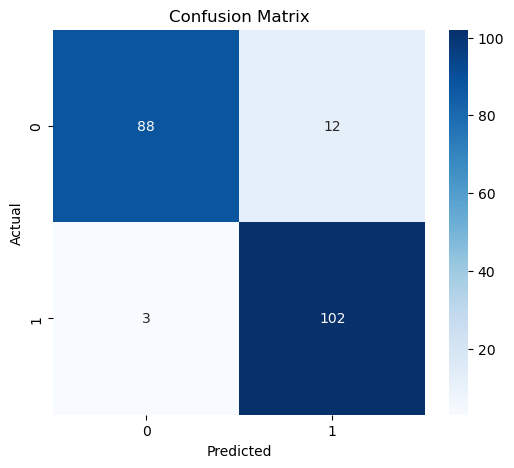

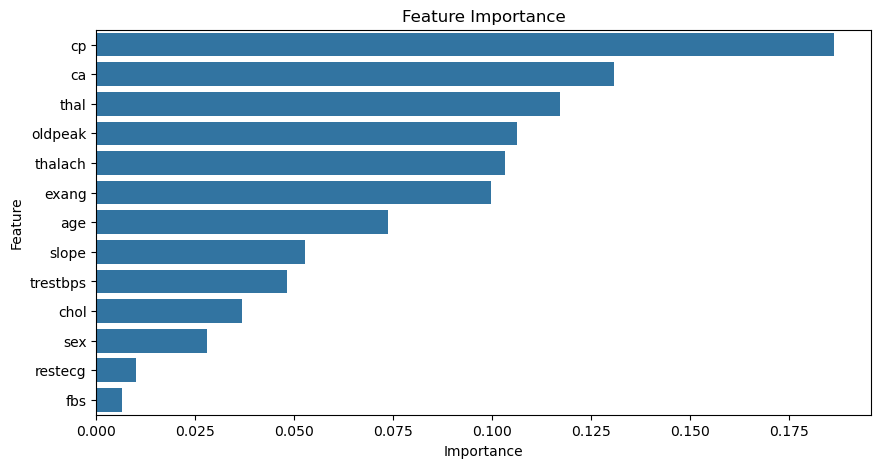


Prediction : No Heart Disease


In [7]:
# ---------------------------------------------------------
# HEART DISEASE CLASSIFICATION
# USING RANDOM FOREST
# ---------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ---------------------------------------------------------
# Step 1 : Load Dataset
# ---------------------------------------------------------

data = pd.read_csv("heart.csv")

print("Dataset Loaded Successfully")
print(data.head())


# ---------------------------------------------------------
# Step 2 : Dataset Information
# ---------------------------------------------------------

print("\nShape :", data.shape)

print("\nMissing Values:\n")
print(data.isnull().sum())

print("\nTarget Distribution:\n")
print(data["target"].value_counts())


# ---------------------------------------------------------
# Step 3 : Feature and Target
# ---------------------------------------------------------

X = data.drop("target", axis=1)
y = data["target"]


# ---------------------------------------------------------
# Step 4 : Train-Test Split
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ---------------------------------------------------------
# Step 5 : Build and Train Model
# ---------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Training Completed")


# ---------------------------------------------------------
# Step 6 : Cross Validation
# ---------------------------------------------------------

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print("\nCross Validation Accuracy :", cv_scores.mean())


# ---------------------------------------------------------
# Step 7 : Prediction
# ---------------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------------
# Step 8 : Accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy :", accuracy)


# ---------------------------------------------------------
# Step 9 : Classification Report
# ---------------------------------------------------------

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


# ---------------------------------------------------------
# Step 10 : Confusion Matrix
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ---------------------------------------------------------
# Step 11 : Feature Importance
# ---------------------------------------------------------

importance = model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)


plt.figure(figsize=(10,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feat_df
)

plt.title("Feature Importance")

plt.show()


# ---------------------------------------------------------
# Step 12 : Example Prediction
# ---------------------------------------------------------

sample = X_test.iloc[0:1]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("\nPrediction : Heart Disease Detected")
else:
    print("\nPrediction : No Heart Disease")